# Advanced PDF Retrieval & Optimization with LlamaIndex

This notebook builds on our previous exploration of embeddings and chunking to demonstrate advanced retrieval techniques using PDF documents. We'll explore query expansion, hybrid retrieval, and reranking to optimize the quality of search results.

## Section 1: Loading PDFs with PyMuPDF & LlamaIndex

### Why are we switching to PDFs?
- Most real-world document search tasks involve PDFs, not plain text
- Using PyMuPDF allows for better text extraction with preserved structure
- Working with PDFs introduces real-world challenges in document processing

### Installation

In [1]:
# ============================================
# STEP 0: Install Required Libraries
# ============================================
#
# WHAT WE'RE DOING:
# Installing libraries for PDF processing, AI queries, and embeddings.
#
# WHY THIS MATTERS:
# PyMuPDF reads PDFs, LlamaIndex manages the RAG pipeline, Gemini provides AI responses.
#
# WHAT YOU'LL SEE:
# Download progress bars. This may take a few minutes.
#
# TROUBLESHOOTING: If you see errors, try running this cell again.
# ============================================

# Install required libraries
!pip install -q llama-index llama-index-llms-gemini pymupdf
!pip install -q llama-index-embeddings-huggingface
!pip install -q nest_asyncio
!pip install -q llama-index-retrievers-bm25
!pip install -q sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 92.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.5/164.5 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.6/142.6 kB 10.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
torch 2.11.0+cpu requires setuptools<82, but you have setuptools 83.0.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

### Setting up the environment

In [ ]:
# ============================================
# STEP 1: Set Up Environment and API Key
# ============================================
#
# WHAT WE'RE DOING:
# Loading our tools and setting the API key for Google's Gemini AI.
#
# WHY THIS MATTERS:
# The API key lets our code communicate with Gemini to generate responses.
#
# WHAT YOU'LL SEE:
# No output — everything is set up silently.
#
# TROUBLESHOOTING:
# - Get your free API key at: https://aistudio.google.com/app/apikey
# - If you see "API key not valid" later, double-check your key
# ============================================

import os
import fitz  # PyMuPDF
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
import nest_asyncio

nest_asyncio.apply()

# Set up Google API key for Gemini
GOOGLE_API_KEY = "YOUR_API_KEY_HERE"  # Replace with your actual API key
os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY

if GOOGLE_API_KEY == "YOUR_API_KEY_HERE":
    print("⚠️ WARNING: Please replace YOUR_API_KEY_HERE with your actual API key!")
    print("Get one free at: https://aistudio.google.com/app/apikey")

# Create a directory for our PDFs if it doesn't exist
!mkdir -p sample_docs

### Loading and Exploring PDF Documents

First, let's see how to load and extract text from a PDF using PyMuPDF:

In [3]:
# ============================================
# STEP 2: Define PDF Upload Function
# ============================================
#
# WHAT WE'RE DOING:
# Creating a helper function that lets you upload a PDF file.
#
# WHY THIS MATTERS:
# We need a real PDF document to test our retrieval system on.
#
# WHAT YOU'LL SEE:
# No output yet — this just defines the function.
# ============================================

from google.colab import files
import os

def upload_pdf():
    """Upload a PDF file and return its path."""
    print("Please select a PDF file to upload:")
    uploaded = files.upload()

    for filename in uploaded.keys():
        if filename.endswith('.pdf'):
            # Save to the sample_docs directory
            pdf_path = os.path.join("sample_docs", filename)

            # Create directory if it doesn't exist
            os.makedirs("sample_docs", exist_ok=True)

            # Save the file
            with open(pdf_path, 'wb') as f:
                f.write(uploaded[filename])

            print(f"PDF saved to {pdf_path}")
            return pdf_path
        else:
            print(f"File {filename} is not a PDF. Please upload a PDF file.")

    return None

Here you should upload a digital PDF (PDF where you can select some text). If you don't have a PDF, you can use the `sample-sdf-document.pdf` included in this project folder (originally from Project 3). Upload it when prompted below.

In [4]:
# ============================================
# STEP 3: Upload Your PDF
# ============================================
#
# WHAT WE'RE DOING:
# Running the upload function — a file picker will appear.
# Upload the sample-sdf-document.pdf file from this project folder.
#
# WHAT YOU'LL SEE:
# A file upload button. Select your PDF and wait for the confirmation message.
# ============================================

# Uncomment to upload your own PDF
pdf_path = upload_pdf()

Please select a PDF file to upload:


Saving sample-sdf-document.pdf to sample-sdf-document.pdf
PDF saved to sample_docs/sample-sdf-document.pdf


In [ ]:
#  Uncomment if you would like to add your own path
# pdf_path = "/content/sample_docs/sample-sdf-document.pdf"

In [5]:
# ============================================
# STEP 4: Define Text Extraction Function
# ============================================
#
# WHAT WE'RE DOING:
# Creating a function to extract text from PDF pages using PyMuPDF.
#
# WHY THIS MATTERS:
# Before AI can search a PDF, we need to convert it from a visual format to text.
#
# WHAT YOU'LL SEE:
# No output yet — we're just defining the function.
# ============================================

def extract_text_from_pdf(pdf_path):
    """Extract text from a PDF file using PyMuPDF."""
    doc = fitz.open(pdf_path)

    # Extract text from all pages
    text = "\n".join([page.get_text() for page in doc])

    # Print some stats
    print(f"PDF: {pdf_path}")
    print(f"Number of pages: {len(doc)}")
    print(f"Extracted {len(text.split())} words from the PDF.")

    # Close the document
    doc.close()

    return text

In [6]:
# ============================================
# STEP 5: Extract Text from Your PDF
# ============================================
#
# WHAT WE'RE DOING:
# Extracting text from your uploaded PDF and showing a preview.
#
# WHAT YOU'LL SEE:
# Page count, word count, and the first 500 characters of text.
# ============================================

# Example usage (after uploading a PDF):
if pdf_path:
    text = extract_text_from_pdf(pdf_path)
    print(text[:500])  # Print first 500 characters

PDF: sample_docs/sample-sdf-document.pdf
Number of pages: 3
Extracted 617 words from the PDF.
Cytiva
100 Results Way
Marlborough, MA 01752
United States
Page 1 / 1
cytiva.com
3 June, 2022
Re: ÄKTATM ready Flow Kit Storage Conditions
To Whom It May Concern,
The recommended storage temperature for standard ÄKTA ready flow kits is provided in Section 8.3 of the Operating 
Instructions 28960345 and specified as > +5 C. This recommendation also applies to all modified ÄKTA ready flow kits 
as well, including the two listed in the below table. Extended storage below the recommended +5
could le


### Integrating PyMuPDF with LlamaIndex

Now let's set up a custom loader to integrate PyMuPDF with LlamaIndex:

In [7]:
# ============================================
# STEP 6: Define LlamaIndex Document Loader
# ============================================
#
# WHAT WE'RE DOING:
# Creating a function that converts PDF pages into LlamaIndex Document objects.
#
# WHY THIS MATTERS:
# LlamaIndex needs documents in a specific format to index and search them.
#
# WHAT YOU'LL SEE:
# No output yet — we're just defining the function.
# ============================================

from llama_index.core import Document
from typing import List

def load_pdf_with_pymupdf(pdf_path: str) -> List[Document]:
    """Load a PDF and convert it to LlamaIndex Document format using PyMuPDF."""
    # Open the PDF
    doc = fitz.open(pdf_path)

    # Extract text from each page
    documents = []

    for i, page in enumerate(doc):
        text = page.get_text()

        # Skip empty pages
        if not text.strip():
            continue

        # Create Document object with metadata
        documents.append(
            Document(
                text=text,
                metadata={
                    "file_name": os.path.basename(pdf_path),
                    "page_number": i + 1,
                    "total_pages": len(doc)
                }
            )
        )

    # Close the document
    doc.close()

    # Print stats
    print(f"Processed {pdf_path}:")
    print(f"Extracted {len(documents)} pages with content")

    return documents

In [8]:
# ============================================
# STEP 7: Load PDF into LlamaIndex Format
# ============================================
#
# WHAT WE'RE DOING:
# Loading the PDF into LlamaIndex format.
#
# WHAT YOU'LL SEE:
# How many pages with content were extracted.
# ============================================

# Example usage:
pdf_docs = load_pdf_with_pymupdf(pdf_path)

Processed sample_docs/sample-sdf-document.pdf:
Extracted 3 pages with content


## Section 2: Indexing and Processing PDFs

Let's create the indexing infrastructure first:

In [9]:
# ============================================
# STEP 8: Set Up AI Models and Indexing Function
# ============================================
#
# WHAT WE'RE DOING:
# Setting up the AI models and creating a searchable index from our PDF.
#
# WHY THIS MATTERS:
# The index is like a smart table of contents that lets AI find relevant sections instantly.
#
# WHAT YOU'LL SEE:
# Confirmation that Gemini and the embedding model are ready.
# ============================================

from llama_index.llms.gemini import Gemini
from llama_index.core import Settings
from llama_index.core import VectorStoreIndex
from llama_index.embeddings.huggingface import HuggingFaceEmbedding

# Initialize Gemini LLM
llm = Gemini(model="models/gemini-2.5-flash")
Settings.llm = llm

# Initialize embedding model
embed_model = HuggingFaceEmbedding(model_name="sentence-transformers/all-MiniLM-L6-v2")
Settings.embed_model = embed_model

def process_and_index_pdf(pdf_path):
    """Process a PDF and create both vector and keyword indices."""
    # Load documents
    documents = load_pdf_with_pymupdf(pdf_path)

    # Create vector index
    vector_index = VectorStoreIndex.from_documents(documents)

    print(f"Indexed {len(documents)} document chunks")

    return vector_index

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)
/tmp/ipykernel_12945/1399702170.py:21: DeprecationWarning: Call to deprecated class Gemini. (Should use `llama-index-llms-google-genai` instead, using Google's latest unified SDK. See: https://docs.llamaindex.ai/en/stable/examples/llm/google_genai/This package will no longer be supported after version 0.6.2) -- Deprecated since version 0.6.2.
  llm = Gemini(model="models/gemini-2.5-flash")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [10]:
# ============================================
# STEP 9: Index the PDF
# ============================================
#
# WHAT WE'RE DOING:
# Indexing the PDF — this converts it into searchable vector embeddings.
#
# WHAT YOU'LL SEE:
# Confirmation showing how many document chunks were indexed.
# ============================================

index = process_and_index_pdf(pdf_path)

Processed sample_docs/sample-sdf-document.pdf:
Extracted 3 pages with content
Indexed 3 document chunks


## Section 2: Implement Query Expansion & Rewriting

Query expansion helps improve retrieval by adding relevant terms to the original query.

In [11]:
# ============================================
# STEP 10: Define Query Expansion Function
# ============================================
#
# WHAT WE'RE DOING:
# Creating a function that rewrites queries to improve search results.
#
# WHY THIS MATTERS:
# Users often phrase questions differently from how documents are written.
# Query expansion adds related terms so the search finds more relevant results.
#
# WHAT YOU'LL SEE:
# No output yet — we're defining the function.
# ============================================

# Gemini was already configured in STEP 8 above

# Simple query expansion function using Gemini
def expand_query(query: str, num_expansions: int = 3) -> list:
    """Expand a query to include related terms using Gemini."""
    prompt = f"""
    I need to search a pharmaceutical quality document with this query: "{query}"

    Please help me expand this query by generating {num_expansions} alternative versions that:
    1. Use different but related terminology
    2. Include relevant pharmaceutical/quality terms that might appear in a certificate or SDF
    3. Cover similar concepts but phrased differently

    Format your response as a list of alternative queries only, with no additional text.
    """

    response = llm.complete(prompt)

    # Extract the expanded queries
    expanded_queries = [line.strip() for line in response.text.split('\n') if line.strip()]

    # Add the original query if needed
    if query not in expanded_queries:
        expanded_queries = [query] + expanded_queries

    return expanded_queries

In [12]:
# ============================================
# STEP 11: Test Query Expansion
# ============================================
#
# WHAT WE'RE DOING:
# Testing query expansion with a sample pharmaceutical question.
#
# WHAT YOU'LL SEE:
# The original query plus expanded versions with related terms.
# ============================================

# Example usage:
expanded = expand_query("What test methods were used for quality control?")
for i, q in enumerate(expanded):
    print(f"{i+1}. {q}")

1. What test methods were used for quality control?
2. *   Which analytical procedures were employed for product release testing?
3. *   What assays and analytical techniques were applied to verify compliance with specifications?
4. *   Please list the methodologies utilized for batch release and in-process quality checks.


### Creating a Query Expansion Engine

Now let's implement a more structured query expansion using LlamaIndex's built-in functionality:

In [13]:
# ============================================
# STEP 12: Build Query Expansion Engine
# ============================================
#
# WHAT WE'RE DOING:
# Building a more advanced query engine that automatically expands queries.
#
# WHY THIS MATTERS:
# QueryFusionRetriever generates multiple versions of your question and combines results.
#
# WHAT YOU'LL SEE:
# No output — the engine is ready to use.
# ============================================

from llama_index.core.query_engine import RetrieverQueryEngine
from llama_index.core.retrievers import QueryFusionRetriever

# Function to create a query engine that uses query expansion
def create_query_expansion_engine(index):
    """Create a query engine that uses query expansion."""
    # First create multiple retrievers (base retriever)
    base_retriever = index.as_retriever(similarity_top_k=2)

    # Create a query fusion retriever
    fusion_retriever = QueryFusionRetriever(
        retrievers=[base_retriever],
        llm=llm,
        similarity_top_k=2,
        num_queries=3,  # Generate 3 queries per original query
        mode="reciprocal_rerank"  # Use reciprocal rank fusion
    )

    # Create the query engine with the fusion retriever
    query_engine = RetrieverQueryEngine.from_args(
        retriever=fusion_retriever,
        llm=llm,
        verbose=True
    )

    return query_engine

In [14]:
# ============================================
# STEP 13: Test the Query Expansion Engine
# ============================================
#
# WHAT WE'RE DOING:
# Testing the query expansion engine with a real question.
#
# WHAT YOU'LL SEE:
# An AI-generated answer based on the PDF content.
# ============================================

# Example usage:
expanded_query_engine = create_query_expansion_engine(index)
response = expanded_query_engine.query("What test methods were used for quality control?")
print(response)

The quality control test methods included Autoclave for pump tubing, Gamma Irradiation for inlets, Flow Rate Test, Pressure Integrity, Visual Inspection, and Package Integrity.


In [15]:
# ============================================
# STEP 14: Note about BM25
# ============================================
#
# The BM25 library (llama-index-retrievers-bm25) was already installed
# in STEP 0 at the top of this notebook. No additional installation needed.
#
# BM25 is a keyword-based search algorithm — we'll combine it with
# vector search in the next section.
# ============================================
print("BM25 library was already installed in Step 0 — ready to use!")

BM25 library was already installed in Step 0 — ready to use!


## Section 3: Implement Hybrid Retrieval (Keyword + Vector Search)

Hybrid retrieval combines embedding-based semantic search with keyword-based retrieval for better results.

In [16]:
# ============================================
# STEP 15: Build Hybrid Retriever
# ============================================
#
# WHAT WE'RE DOING:
# Building a hybrid retriever that combines vector search (meaning) + keyword search (exact matches).
#
# WHY THIS MATTERS:
# Neither method alone is perfect — combining them gives the best of both worlds.
#
# WHAT YOU'LL SEE:
# No output — the function is ready to use.
# ============================================

from llama_index.core import VectorStoreIndex
from llama_index.retrievers.bm25 import BM25Retriever

def create_hybrid_retriever(index, query, top_k=2):
    """Create a hybrid retrieval approach combining vector and keyword search."""
    # Method 1: Vector retrieval (semantic search)
    vector_retriever = index.as_retriever(similarity_top_k=top_k)
    vector_nodes = vector_retriever.retrieve(query)

    # Method 2: BM25 retrieval (keyword-based search)
    # Get all nodes from the index
    nodes = [node for node in index.docstore.docs.values()]
    bm25_retriever = BM25Retriever.from_defaults(
        nodes=nodes,
        similarity_top_k=top_k
    )
    keyword_nodes = bm25_retriever.retrieve(query)

    # Combine results (simple approach)
    all_nodes = []
    all_nodes.extend(vector_nodes)
    all_nodes.extend(keyword_nodes)

    # Remove duplicates
    unique_nodes = []
    seen_ids = set()
    for node in all_nodes:
        if node.node_id not in seen_ids:
            unique_nodes.append(node)
            seen_ids.add(node.node_id)

    # Sort by score (higher is better)
    sorted_nodes = sorted(unique_nodes, key=lambda x: x.score if hasattr(x, 'score') else 0.0, reverse=True)

    # Limit to top results
    top_nodes = sorted_nodes[:top_k]

    return top_nodes

In [17]:
# ============================================
# STEP 16: Test Hybrid Retrieval
# ============================================
#
# WHAT WE'RE DOING:
# Testing hybrid retrieval with a pharmaceutical question.
#
# WHAT YOU'LL SEE:
# Retrieved text passages from the PDF, ranked by relevance score.
# ============================================

# Example usage:
hybrid_nodes = create_hybrid_retriever(index, "What are the storage conditions for this product?")
for i, node in enumerate(hybrid_nodes):
    print(f"Result {i+1} (Score: {node.score:.4f}):")
    print(node.get_text())
    print("-" * 40)

DEBUG:bm25s:Building index from IDs objects


Result 1 (Score: 0.2682):
Cytiva
100 Results Way
Marlborough, MA 01752
United States
Page 1 / 1
cytiva.com
3 June, 2022
Re: ÄKTATM ready Flow Kit Storage Conditions
To Whom It May Concern,
The recommended storage temperature for standard ÄKTA ready flow kits is provided in Section 8.3 of the Operating 
Instructions 28960345 and specified as > +5 C. This recommendation also applies to all modified ÄKTA ready flow kits 
as well, including the two listed in the below table. Extended storage below the recommended +5
could lead to 
brittleness or cracking of the plastic connectors. However, the operating temperature of ÄKTA ready flow kits is +2 C to 
+40 C. If the kits are allowed to acclimate to a warmer temperature before being used this would reduce the risk of
damage to the kit during setup and handling.
Description
Part Number
Operating Temperature
High Flow Kit F, Modified, ÄKTA ready
29477427
+2 C to +40 C
High Flow Gradient C, Modified, ÄKTA ready
29184612
+2 C to +40 C
Operating I

### Comparing Retrieval Methods

Let's create a function to compare different retrieval methods:

In [18]:
# ============================================
# STEP 17: Define Retrieval Comparison Function
# ============================================
#
# WHAT WE'RE DOING:
# Creating a comparison function to see how different retrieval methods perform.
#
# WHY THIS MATTERS:
# Seeing results side-by-side helps you understand why hybrid search is powerful.
#
# WHAT YOU'LL SEE:
# No output — the function is defined and ready.
# ============================================

def compare_retrieval_methods(index, query, top_k=2):
    """Compare different retrieval methods for the same query."""
    # Vector retrieval
    vector_retriever = index.as_retriever(similarity_top_k=top_k)
    vector_nodes = vector_retriever.retrieve(query)

    # Keyword retrieval (BM25)
    nodes = [node for node in index.docstore.docs.values()]
    keyword_retriever = BM25Retriever.from_defaults(
        nodes=nodes,
        similarity_top_k=top_k
    )
    keyword_nodes = keyword_retriever.retrieve(query)

    # Hybrid retrieval
    hybrid_nodes = create_hybrid_retriever(index, query, top_k)

    # Create a comparison dataframe
    results = []

    for method, nodes in [
        ("Vector (Semantic)", vector_nodes),
        ("Keyword (BM25)", keyword_nodes),
        ("Hybrid", hybrid_nodes)
    ]:
        for i, node in enumerate(nodes):
            results.append({
                "Method": method,
                "Rank": i + 1,
                "Score": node.score if hasattr(node, 'score') else 0.0,
                "Content": node.get_text()[:200] + "...",  # First 200 chars
                "Page": node.metadata.get("page_number", "Unknown") if hasattr(node, 'metadata') else "Unknown"
            })

    results_df = pd.DataFrame(results)
    display(results_df)

    # Visualize scores
    plt.figure(figsize=(10, 6))
    for method in ["Vector (Semantic)", "Keyword (BM25)", "Hybrid"]:
        method_df = results_df[results_df["Method"] == method]
        plt.bar(
            [f"{method} - Rank {row['Rank']}" for _, row in method_df.iterrows()],
            method_df["Score"],
            alpha=0.7,
            label=method
        )

    plt.xlabel("Result")
    plt.ylabel("Retrieval Score")
    plt.title(f"Comparison of Retrieval Methods for Query: '{query}'")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return results_df

DEBUG:bm25s:Building index from IDs objects
DEBUG:bm25s:Building index from IDs objects


,Method,Rank,Score,Content,Page
0,Vector (Semantic),1,0.268225,"Cytiva\n100 Results Way\nMarlborough, MA 01752...",1
1,Vector (Semantic),2,0.173014,Cytiva\ncytiva.com\nCertificate of Quality\nTh...,3
2,Keyword (BM25),1,1.128970,"Cytiva\n100 Results Way\nMarlborough, MA 01752...",1
3,Keyword (BM25),2,0.106825,Certificate of Quality \nThis product is manuf...,2
4,Hybrid,1,0.268225,"Cytiva\n100 Results Way\nMarlborough, MA 01752...",1
5,Hybrid,2,0.173014,Cytiva\ncytiva.com\nCertificate of Quality\nTh...,3


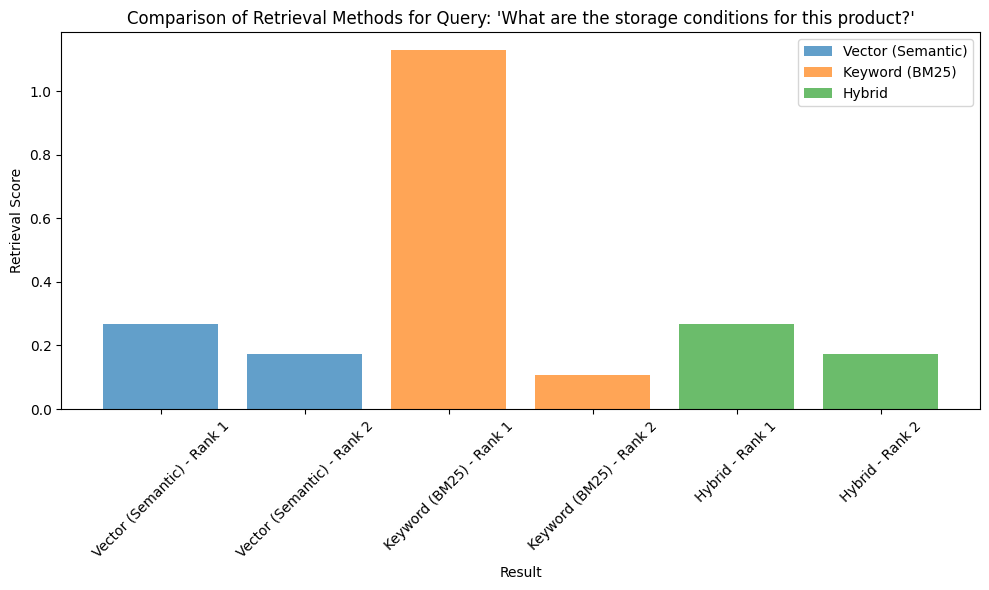

In [19]:
# ============================================
# STEP 18: Run Retrieval Comparison
# ============================================
#
# WHAT WE'RE DOING:
# Comparing vector, keyword, and hybrid retrieval for the same query.
#
# WHAT YOU'LL SEE:
# A table and bar chart comparing scores across all three methods.
# ============================================

# Example usage:
comparison = compare_retrieval_methods(index, "What are the storage conditions for this product?")

## Section 4: Implement Reranking for More Accurate Results

Reranking helps prioritize the most relevant results after initial retrieval.

In [20]:
# ============================================
# STEP 19: Demonstrate Reranking
# ============================================
#
# WHAT WE'RE DOING:
# Using a reranker to re-sort retrieved results by true relevance.
#
# WHY THIS MATTERS:
# Initial retrieval may rank results poorly — reranking fixes the order.
#
# WHAT YOU'LL SEE:
# Before and after comparison showing how reranking changes result ordering.
# ============================================

from llama_index.core.postprocessor import SentenceTransformerRerank
from llama_index.core.schema import NodeWithScore

# Create a reranker
def rerank_results(nodes, query, top_n=2):
    """Rerank retrieved nodes using the Sentence Transformer reranker."""
    # Create the reranker
    reranker = SentenceTransformerRerank(
        model="cross-encoder/ms-marco-MiniLM-L-6-v2",
        top_n=top_n
    )

    # Rerank the nodes
    reranked_nodes = reranker.postprocess_nodes(
        nodes,
        query_str=query
    )

    return reranked_nodes

# Function to demonstrate the reranking process
def demonstrate_reranking(index, query, top_k=3):
    """Demonstrate the reranking process on retrieval results."""
    # First retrieve more nodes than we need
    retriever = index.as_retriever(similarity_top_k=top_k)
    nodes = retriever.retrieve(query)

    print(f"Query: {query}")
    print("\nOriginal Retrieval Order:")
    for i, node in enumerate(nodes):
        print(f"{i+1}. (Score: {node.score:.4f}) - {node.get_text()[:100]}...")

    # Now rerank them
    reranked_nodes = rerank_results(nodes, query, top_n=2)

    print("\nAfter Reranking:")
    for i, node in enumerate(reranked_nodes):
        print(f"{i+1}. (Score: {node.score:.4f}) - {node.get_text()[:100]}...")

    # Create comparison dataframe
    results = []

    # Original ranking
    for i, node in enumerate(nodes):
        results.append({
            "Stage": "Original Retrieval",
            "Rank": i + 1,
            "Score": node.score,
            "Content": node.get_text()[:150] + "...",
            "Page": node.metadata.get("page_number", "Unknown")
        })

    # Reranked
    for i, node in enumerate(reranked_nodes):
        results.append({
            "Stage": "After Reranking",
            "Rank": i + 1,
            "Score": node.score,
            "Content": node.get_text()[:150] + "...",
            "Page": node.metadata.get("page_number", "Unknown")
        })

    results_df = pd.DataFrame(results)
    display(results_df)

    return results_df

# Example usage:
reranking_demo = demonstrate_reranking(index, "What sterilization method was used?", top_k=3)

Query: What sterilization method was used?

Original Retrieval Order:
1. (Score: 0.2139) - Certificate of Quality 
This product is manufactured in compliance with our ISO 9001 certified quali...
2. (Score: 0.2115) - Cytiva
cytiva.com
Certificate of Quality
This product is manufactured in compliance with our ISO 900...
3. (Score: 0.1843) - Cytiva
100 Results Way
Marlborough, MA 01752
United States
Page 1 / 1
cytiva.com
3 June, 2022
Re: ÄK...


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]


After Reranking:
1. (Score: -11.1406) - Cytiva
cytiva.com
Certificate of Quality
This product is manufactured in compliance with our ISO 900...
2. (Score: -11.2391) - Certificate of Quality 
This product is manufactured in compliance with our ISO 9001 certified quali...


,Stage,Rank,Score,Content,Page
0,Original Retrieval,1,-11.239133,Certificate of Quality \nThis product is manuf...,2
1,Original Retrieval,2,-11.140560,Cytiva\ncytiva.com\nCertificate of Quality\nTh...,3
2,Original Retrieval,3,-11.253381,"Cytiva\n100 Results Way\nMarlborough, MA 01752...",1
3,After Reranking,1,-11.140560,Cytiva\ncytiva.com\nCertificate of Quality\nTh...,3
4,After Reranking,2,-11.239133,Certificate of Quality \nThis product is manuf...,2


## Complete End-to-End Example - Building an Advanced RAG Pipeline

Now let's combine all these techniques into an advanced RAG pipeline:

In [21]:
# ============================================
# STEP 20: Build Complete RAG Pipeline
# ============================================
#
# WHAT WE'RE DOING:
# Building the complete RAG pipeline combining hybrid retrieval + reranking.
#
# WHY THIS MATTERS:
# This is the final product — a production-quality document search system.
#
# WHAT YOU'LL SEE:
# No output — the pipeline function is defined and ready.
# ============================================

from llama_index.core.query_engine import RetrieverQueryEngine
from llama_index.core.postprocessor import SentenceTransformerRerank
from llama_index.retrievers.bm25 import BM25Retriever
from llama_index.core.retrievers import BaseRetriever
from llama_index.core.schema import NodeWithScore, QueryBundle

def build_rag_pipeline(index):
    """Build a simple but effective RAG pipeline with hybrid retrieval and reranking."""

    # Get all nodes from the index's docstore
    nodes = list(index.docstore.docs.values())

    # Determine safe top_k value (number of nodes to retrieve)
    # Must be at least 1 and no more than the number of available nodes
    num_nodes = len(nodes)
    safe_top_k = min(2, max(1, num_nodes))

    print(f"Index contains {num_nodes} nodes, using top_k={safe_top_k}")

    # Step 1: Create a hybrid retriever combining vector and keyword search
    # First, get the vector retriever (for semantic understanding)
    vector_retriever = index.as_retriever(
        similarity_top_k=safe_top_k  # Retrieve top 2 most similar chunks
    )

    # Next, create a BM25 retriever (for keyword matching)
    bm25_retriever = BM25Retriever.from_defaults(
        nodes=nodes,
        similarity_top_k=safe_top_k  # Retrieve top 2 most similar chunks
    )

    # Create a proper hybrid retriever class
    class HybridRetriever(BaseRetriever):
        """Hybrid retriever that combines vector and keyword search results."""

        def __init__(self, vector_retriever, keyword_retriever, top_k=2):
            """Initialize with vector and keyword retrievers."""
            self.vector_retriever = vector_retriever
            self.keyword_retriever = keyword_retriever
            self.top_k = top_k
            super().__init__()

        def _retrieve(self, query_bundle, **kwargs):
            """Retrieve from both retrievers and combine results."""
            # Get results from both retrievers
            vector_nodes = self.vector_retriever.retrieve(query_bundle)
            keyword_nodes = self.keyword_retriever.retrieve(query_bundle)

            # Combine all nodes
            all_nodes = list(vector_nodes) + list(keyword_nodes)

            # Remove duplicates (by node_id)
            unique_nodes = {}
            for node in all_nodes:
                if node.node_id not in unique_nodes:
                    unique_nodes[node.node_id] = node

            # Sort by score (higher is better)
            sorted_nodes = sorted(
                unique_nodes.values(),
                key=lambda x: x.score if hasattr(x, 'score') else 0.0,
                reverse=True
            )

            return sorted_nodes[:self.top_k]  # Return top results

    # Create our hybrid retriever instance
    hybrid_retriever = HybridRetriever(
        vector_retriever=vector_retriever,
        keyword_retriever=bm25_retriever,
        top_k=safe_top_k
    )

    # Step 2: Create a reranker to prioritize the most relevant chunks
    if num_nodes > 1:
        reranker = SentenceTransformerRerank(
            model="cross-encoder/ms-marco-MiniLM-L-6-v2",
            top_n=min(2, num_nodes)  # Keep only top 2 results after reranking
        )
        node_postprocessors = [reranker]
    else:
        node_postprocessors = []


    # Step 3: Build the query engine
    query_engine = RetrieverQueryEngine.from_args(
        retriever=hybrid_retriever,
        llm=llm,
        node_postprocessors=node_postprocessors
    )

    return query_engine

In [22]:
# ============================================
# STEP 21: Run the Complete RAG Pipeline
# ============================================
#
# WHAT WE'RE DOING:
# Running the complete RAG pipeline on your PDF with a real question.
#
# WHAT YOU'LL SEE:
# The AI's answer based on information retrieved from your pharmaceutical document.
# ============================================

# Example usage:
# NOTE: The PDF was already uploaded in Step 3 above. No need to upload again.
# If you want to use a different PDF, uncomment the next line:
# pdf_path = upload_pdf()
index = process_and_index_pdf(pdf_path)
rag_engine = build_rag_pipeline(index)
response = rag_engine.query("What test methods were used for quality control?")
print('\nFinal Response:\n ---------------------- \n')
print(response)

Processed sample_docs/sample-sdf-document.pdf:
Extracted 3 pages with content


DEBUG:bm25s:Building index from IDs objects


Indexed 3 document chunks
Index contains 3 nodes, using top_k=2


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]


Final Response:
 ---------------------- 

The quality control test methods included Autoclave for pump tubing (121°C > 15 min), Gamma Irradiation for inlets (25.0 – 40.0 kGy), Flow Rate Test (Per SOP-QC-042), Pressure Integrity (Max 0.5 bar, 5 min hold), Visual Inspection (No defects visible), and Package Integrity (Sealed, no damage).


### Why This Approach Works Well

1. **Hybrid Retrieval**: By combining vector search (semantic understanding) with BM25 (keyword matching), we get the best of both worlds:
   - Vector search finds semantically related content even if keywords don't match
   - BM25 ensures we don't miss exact term matches that might be relevant

2. **Reranking**: The SentenceTransformer reranker provides a second opinion on relevance:
   - It uses a specialized cross-encoder model to score query-chunk pairs
   - This helps filter out chunks that might be tangentially related but not directly relevant
   - Results in higher precision answers with less noise

3. **Simplicity**: This approach avoids complex routing logic while still delivering high-quality results:
   - No need for multiple specialized retrievers with complex selection logic
   - Handles most query types well without additional complexity
   - Easier to maintain and understand

This pipeline will retrieve relevant information from PDFs and generate concise, accurate responses using Gemini's capabilities.

## Conclusion

In this notebook, we explored advanced PDF retrieval techniques with LlamaIndex:

1. Loading and processing PDFs using PyMuPDF
2. Implementing query expansion to improve retrieval quality
3. Using hybrid retrieval to combine semantic and keyword search
4. Applying reranking to prioritize the most relevant results
5. Building an advanced RAG pipeline that combines all these techniques

These techniques can significantly improve the quality of information retrieval from PDFs and other document types in real-world applications.